In [58]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import ceil

In [59]:
print(os.getcwd())
with open("../../scores_withmeta.pickle", "rb") as f:
    scores = pickle.load(f)

if False:
    to_remove = [11]
    for key in scores:
        for i in to_remove:
            for j in range(len(scores[key])):
                if i == j:
                    print("removing", key, i)
                    scores[key].pop(j)
                    break
    with open("../../scores_withmeta.pickle", "wb") as f:
        pickle.dump(scores, f)

#sort which has alpha
for key in scores:
    timeouts = 0
    for i in range(len(scores[key])):
        if "timeout" in scores[key][i] and scores[key][i]["timeout"] == True:
            timeouts += 1
    print(key, timeouts)
    has_alpha = np.zeros((len(scores[key])), dtype=bool)
    for i in range(len(scores[key])):
        if "alpha_actual" in scores[key][i]:
            has_alpha[i] = True
    scores[key] = [scores[key][i] for i in range(len(has_alpha)) if has_alpha[i]]

/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/Condition evaluation Larmor


FileNotFoundError: [Errno 2] No such file or directory: '../../scores_withmeta.pickle'

key not found in 2level 2 commensurate_x_virt_z_nooptim
key not found in 2level 2 commensurate_x_virt_z
Length of set FAST-MAGNUS-MAGNUS: 60


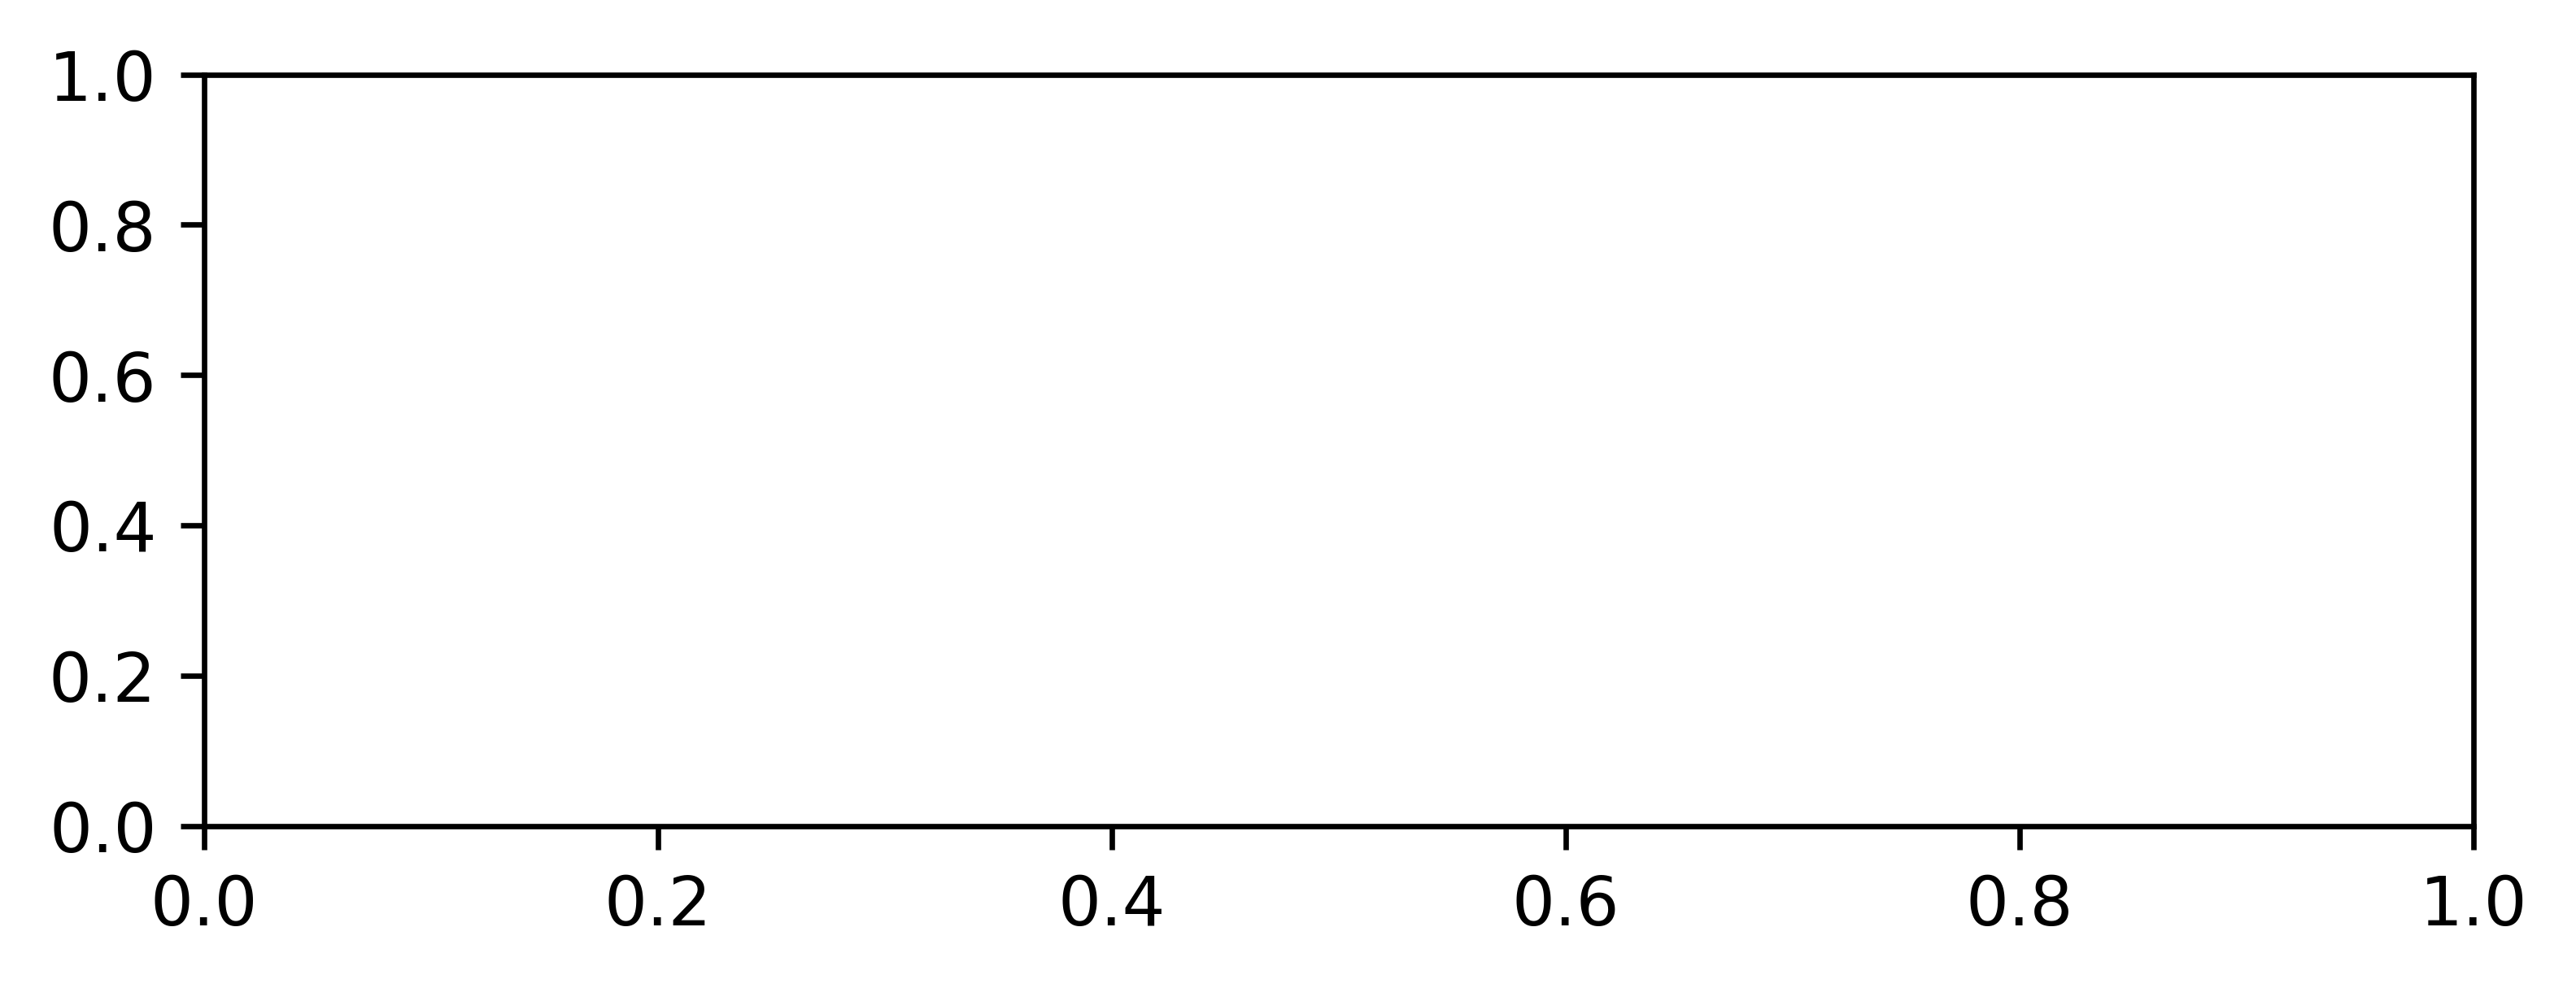

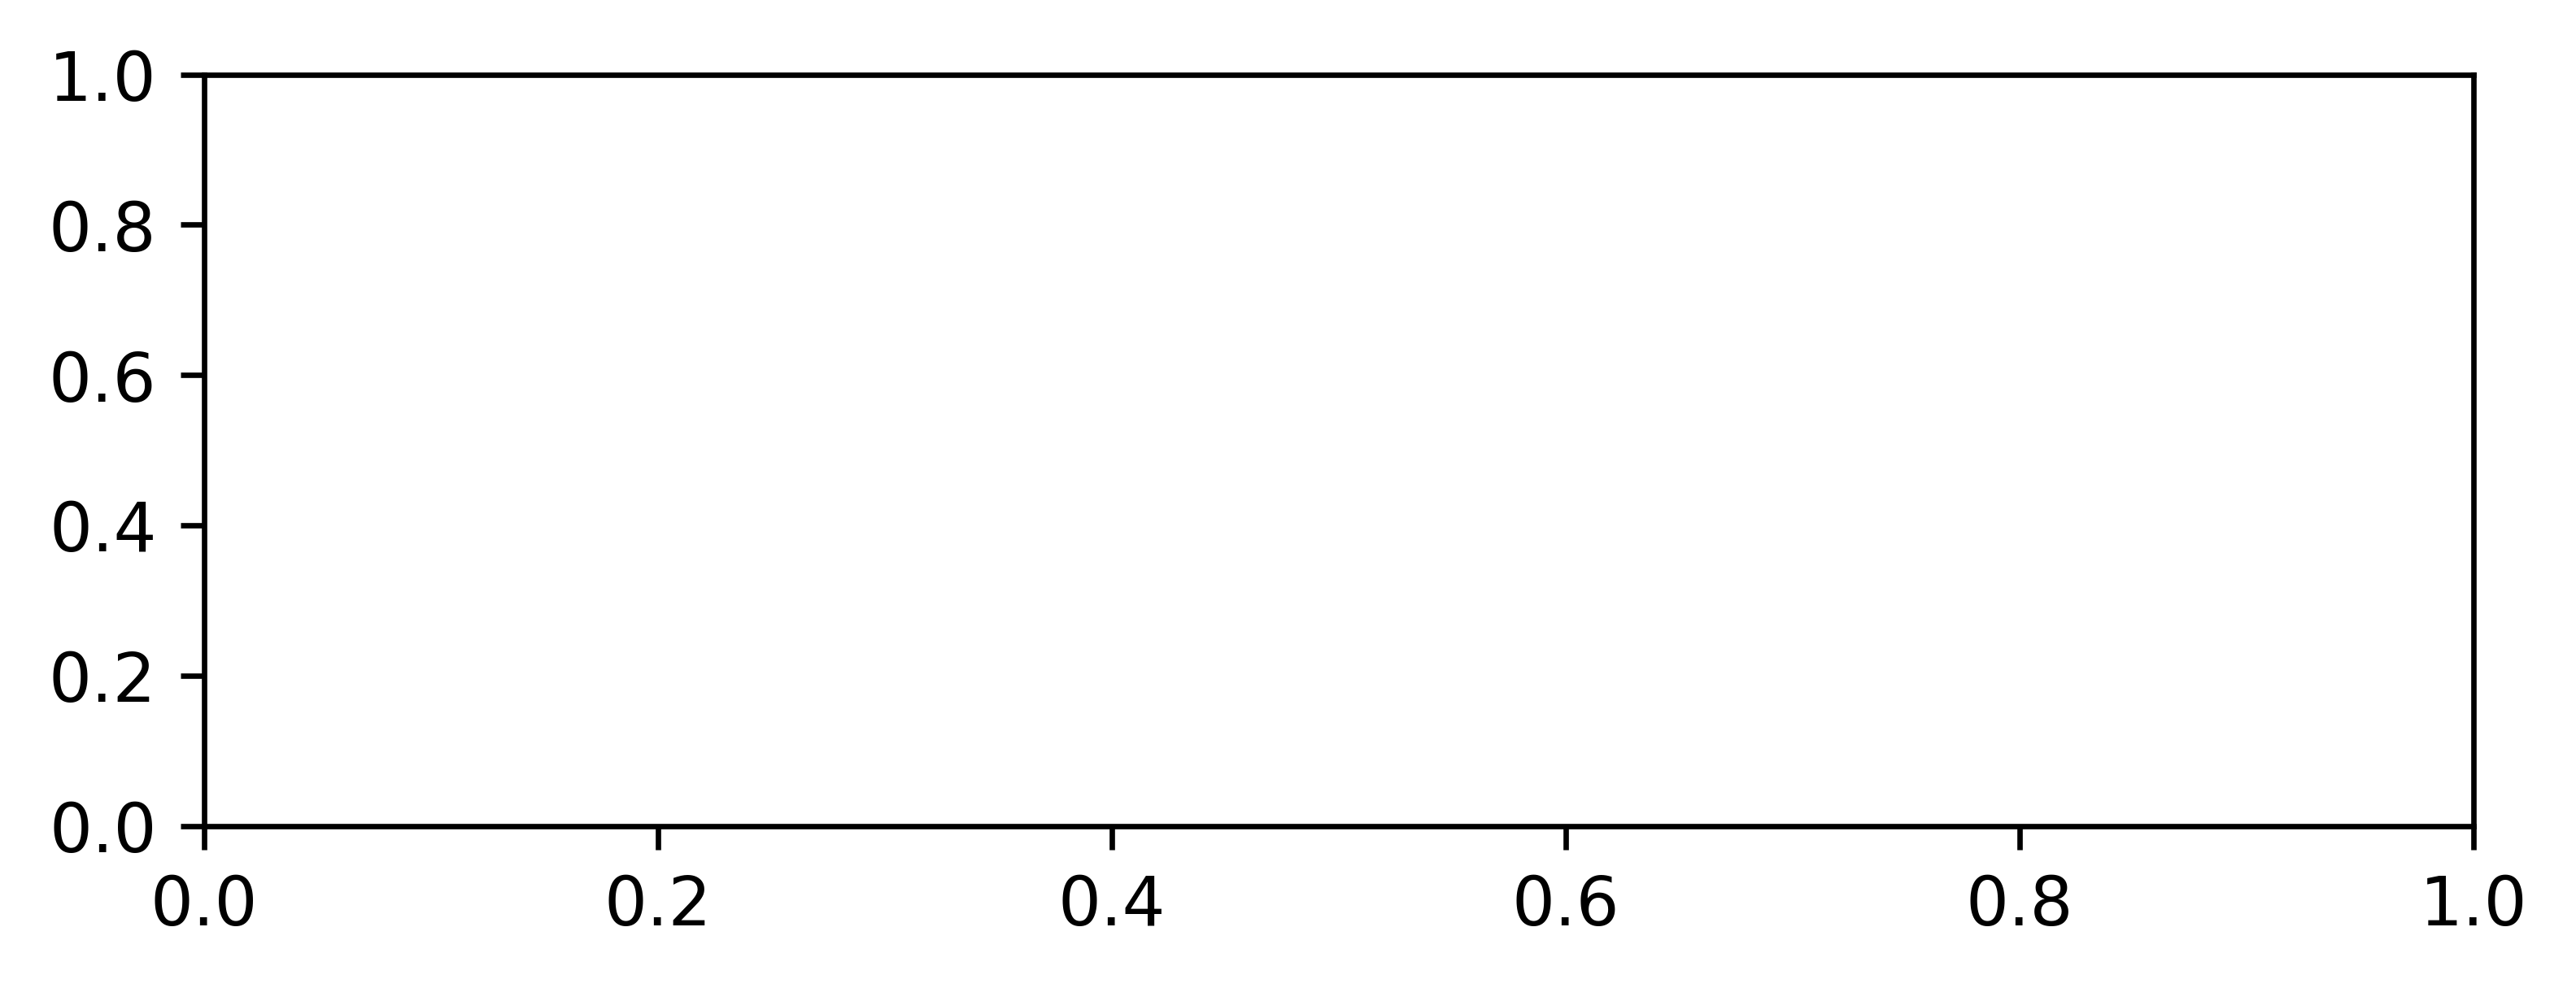

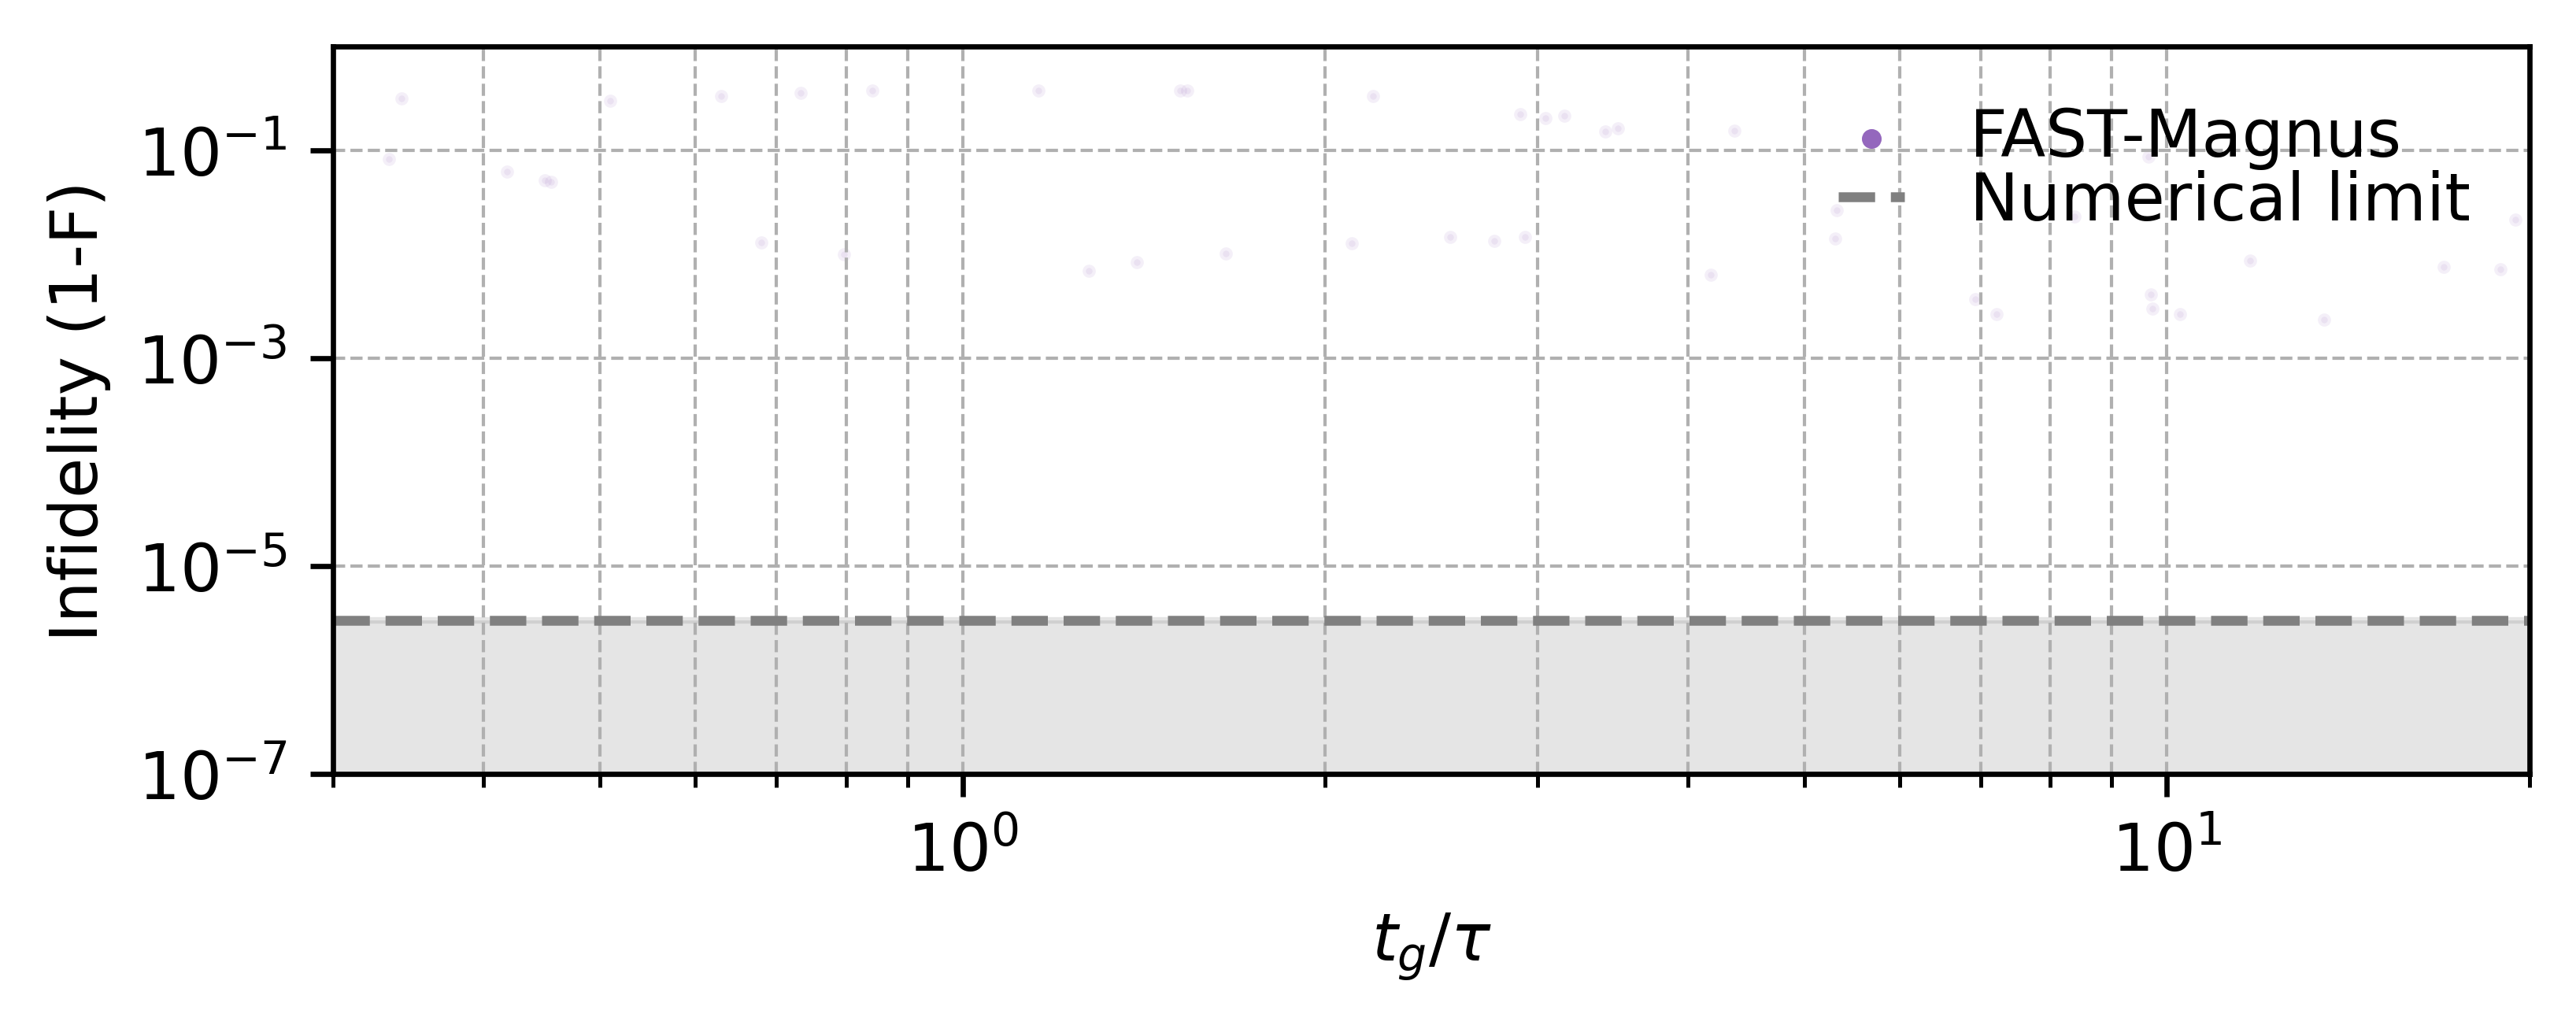

In [4]:
#do_simple
import pickle
import numpy as np
import matplotlib.pyplot as plt
with open("../../scores_withmeta_2levelfinal.pickle", "rb") as f:
    #with open("../../scores_withmeta.pickle", "rb") as f:
    scores_2level_1 = pickle.load(f)
with open("../../scores_withmeta_2levelfinal_justnotFM.pickle", "rb") as f:
    #with open("../../scores_withmeta.pickle", "rb") as f:
    scores_2level_2 = pickle.load(f)
"""with open("../../scores_withmeta.pickle", "rb") as f:
    scores_2level = pickle.load(f)"""
#scores_2level_2 = {k: scores_2level_2[k] for k in scores_2level_2 if "FAST-M" not in k}
for key in scores_2level_1:
    if key in scores_2level_2 and "comm" not in key:
        scores_2level_2[key] += scores_2level_1[key]
    else:
        print("key not found in 2level 2", key)
#for key in scores_2level_3:
#    scores_2level_2[key] = scores_2level_3[key]
scores_2level = scores_2level_2
"""goodkeys = [k for k in scores_2level if "FAST" not in k]
scores_2level = {k: scores_2level[k] for k in goodkeys}
with open("../../scores_withmeta.pickle", "wb") as f:
    pickle.dump(scores_2level, f)"""

with open("../../scores_withmeta.pickle", "rb") as f:
    scores_2level = pickle.load(f)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
def do_simple(scores):
    plt.rcParams.update({
        #"text.usetex": True,
        #"font.family": "Helvetica"
    })
    key_table = {
        "magnus1": "MS",
        "comm": "Commensurate",
        "cor": "Co-rotating",
        "RWA": "RWA conditon",
        "FAST-M": "FAST-Magnus",
        "FAST_n": "FAST",
        "FAST-D": "FAST-DRAG",
    }
    fig, ax = plt.subplots(1, 1, figsize=(6, 2),dpi=600)
    all_lambdas = []
    colors = {
        "cor": "tab:blue",
        "commen": "tab:orange",
        "RWA": "tab:red",
        "FAST-M": "tab:purple",
        "FAST-D": "tab:purple",
        "FAST_n": "tab:purple",
        "magnus": "tab:green",
    }
    for i,key in enumerate(scores):
        lbl = "none"
        """if "comm" in key and "nooptim" in key: continue
        if "FAST_n" in key: continue
        if "FAST-D" in key: continue
        if "FAST-M" in key and "nooptim" not in key: continue
        if "RWA" in key or 'magnus' in key or "FAST-D" in key or "comm" in key or "cor" in key:
            #if "RWA" in key or "cor" in key in key or "magnus" in key or "comm" in key:
            continue"""

        if "old" in key or len(scores[key]) < 1:
            continue
        tgs = []
        omega_01s = []
        lambdas = []
        fidelity = []
        for i in range(len(scores[key])):
            tgs.append(scores[key][i]["t_g"])
            omega_01s.append(scores[key][i]["omega_01_actual"])
            tau = (omega_01s[-1] / (2*np.pi))**(-1)
            lambdas.append(tgs[-1] / tau)
            fidelity.append(scores[key][i]["score"])
        tgs = np.array(tgs)
        omega_01s = np.array(omega_01s)
        lambdas = np.array(lambdas)
        all_lambdas += lambdas.tolist()
        fidelity = np.array(fidelity)
        #plot lambda and score
        #fig, ax = ax.subplots(1, 1, figsize=(8, 6))
        mask = np.argsort(lambdas)
        l2plot = lambdas[mask]
        f2plot = fidelity[mask]
        c = "tab:blue"
        for ck in colors:
            if ck in key:
                c = colors[ck]
        line = "--"
        if "comm" in key and "nooptim" in key: continue
        nanmask = np.isnan(np.asarray(f2plot).astype(float))
        f2plot = f2plot[~nanmask]
        l2plot = l2plot[~nanmask]
        if np.sum(nanmask) > 0:
            print("nanmask", key, np.sum(nanmask))
        #sc = ax.plot(l2plot, 1-f2plot, label=key,c=c, linestyle=line, alpha=alpha)  
        for l in key_table:
            if l in key:
                lbl = key_table[l]
                break
        sc = ax.scatter(l2plot, 1-f2plot, label=rf"{lbl}",c=c, alpha=0.1, s=1, rasterized=True)
        #do a moving average aswell
        N = 100
        #if "comm" in key: N = N//10
        kernel = np.ones(N)
        #kernel = np.exp(-np.linspace(-1, 1, N)**2*10)
        #if "comm" not in key:
        kernel /= np.sum(kernel)
        favg = np.power(10,np.convolve(np.log10(1-f2plot), kernel, mode='valid'))
        lavg = l2plot[N//2:-N//2+1]
        order = np.argsort(lavg)
        lavg = lavg[order]
        favg = favg[order]
        if "comm" not in key:
            ax.plot(lavg, favg, c=c, alpha=0.9, linewidth=1.0)
        else:
            ax.scatter(lavg, favg, c=c, alpha=0.9, s=1)
        #ax.set_xlabel(r"$\Lambda\equiv t_g/\tau$")
        ax.set_xlabel(r"$t_g/\tau$")
        ax.set_ylabel("Infidelity (1-F)")
        #ax.set_title(key)
    #make a horizontal line 2e-6, and grey out all under it
    if len(all_lambdas) > 0:
        mi = np.min(all_lambdas)
        ma = np.max(all_lambdas)
        plt.axhline(y=3e-6, color='grey', linestyle='--', label='Numerical limit')
        plt.fill_betweenx([0, 3e-6], 0, ma, color='grey', alpha=0.2)
        plt.xlim([3e-1, 2e1])
        plt.yscale("log")
        plt.xscale("log")
        plt.ylim([1e-7,1])
        lgnd = plt.legend(fontsize=10, frameon=False,ncol=1, loc='upper right',
                   bbox_to_anchor=(1.0, 1.0), handletextpad=1.0, labelspacing=0.0,
                   columnspacing=0.0, markerscale=2.0,
                     handlelength=1.0)
        for i in range(len(lgnd.legend_handles)):
            lgnd.legend_handles[i]._alpha = 1
        #with grid
        plt.grid(which='both', linestyle='--', linewidth=0.5)
        plt.savefig("fidelity.pdf", bbox_inches='tight',dpi=600)
        plt.show()  


        
for k in scores_2level:
    print(f"Length of set {k}: {len(scores_2level[k])}")
    
do_simple(scores_2level)

alphas [0.5736571  2.37634221]


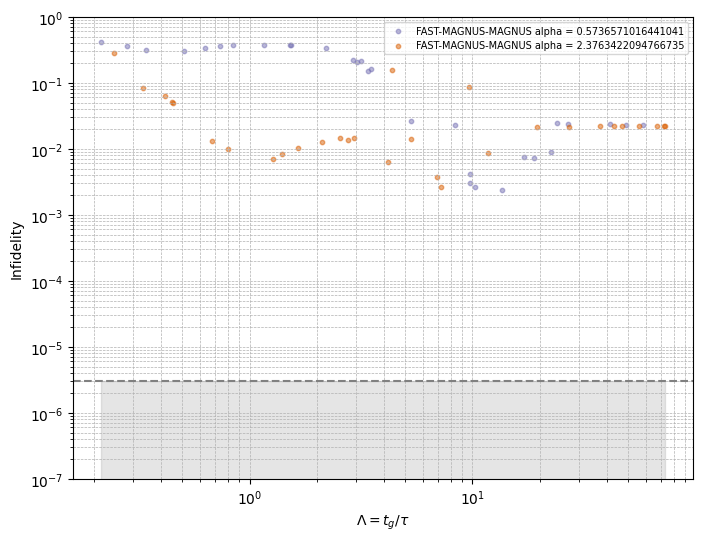

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle
with open("../../scores_withmeta.pickle", "rb") as f:
    scores_alpha = pickle.load(f)
def do_byalpha(scores):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    all_lambdas = []
    colors = {
        "RWA": "#d95f02",
        "MIT": "#7570b3",
        "OTH": "#1b9e77"
    }
    linestyles = {
        "RWA": "-",
        "MIT": "--",
        "OTH": ":"
    }
    alphas = []
    for key in scores:
        for dp in scores[key]:
            if "alpha_actual" in dp:
                alphas.append(dp["alpha_actual"])
    alphas = np.unique(alphas)
    alphas = np.sort(alphas)
    print("alphas", alphas)
    plotted_before = {}
    for a in alphas:
        for i,key in enumerate(scores):
            if key not in plotted_before:
                plotted_before[key] = np.zeros(len(scores[key]), dtype=bool)
            if "old" in key or len(scores[key]) < 1:
                continue
            tgs = []
            omega_01s = []
            alphas = []
            lambdas = []
            fidelity = []
            for i in range(len(scores[key])):
                tgs.append(scores[key][i]["t_g"])
                omega_01s.append(scores[key][i]["omega_01_actual"])
                alphas.append(scores[key][i]["alpha_actual"])
                tau = (omega_01s[-1] / (2*np.pi))**(-1)
                lambdas.append(tgs[-1] / tau)
                fidelity.append(scores[key][i]["score"])
            tgs = np.array(tgs)
            omega_01s = np.array(omega_01s)
            lambdas = np.array(lambdas)
            all_lambdas += lambdas.tolist()
            fidelity = np.array(fidelity)

            alpha_mask = np.isclose(np.array(alphas), a)
            alpha_mask = np.logical_and(alpha_mask, np.logical_not(plotted_before[key]))
            if np.sum(alpha_mask) == 0:
                continue
            tgs = tgs[alpha_mask]
            omega_01s = omega_01s[alpha_mask]
            lambdas = lambdas[alpha_mask]
            fidelity = fidelity[alpha_mask]
            alphas = np.array(alphas)[alpha_mask]
            plotted_before[key][alpha_mask] = True
            #plot lambda and score
            #fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            mask = np.argsort(lambdas)
            l2plot = lambdas[mask]
            f2plot = fidelity[mask]
            c = "none"
            for ck in colors:
                if ck in key:
                    c = colors[ck]
            if c == "none": c = random.choice(list(colors.values()))
            line = "--"
            alpha = 0.5
            if "nooptim" in key:
                line = "-"
                alpha = 1
            nanmask = np.isnan(np.asarray(f2plot).astype(float))
            f2plot = f2plot[~nanmask]
            l2plot = l2plot[~nanmask]
            if np.sum(nanmask) > 0:
                print("nanmask", key, np.sum(nanmask))
            lbl = key + " alpha = " + str(a)
            #sc = ax.plot(l2plot, 1-f2plot, label=lbl,c=c, linestyle=line, alpha=alpha) 
            ax.scatter(l2plot, 1-f2plot, label=lbl, c=c, alpha=alpha, s=10, rasterized=True)
            ax.set_xlabel(r"$\Lambda=t_g/\tau$")
            ax.set_ylabel("Infidelity")
            #ax.set_title(key)
        #make a horizontal line 2e-6, and grey out all under it
    if len(all_lambdas) > 0:
        mi = np.min(all_lambdas)
        ma = np.max(all_lambdas)
        ax.axhline(y=3e-6, color='grey', linestyle='--')
        ax.fill_betweenx([0, 3e-6], mi, ma, color='grey', alpha=0.2)
        #plt.xlim([1e-1, 3e1])
        plt.yscale("log")
        plt.xscale("log")
        plt.ylim([1e-7,1])
        plt.legend(fontsize=7)
        #with grid
        ax.grid(which='both', linestyle='--', linewidth=0.5)
        plt.savefig("fidelity_alpha.png", dpi=300, bbox_inches='tight')
        plt.show()  

do_byalpha(scores_alpha)

In [3]:
import sympy as sp
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from copy import deepcopy as copy
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import pickle
from matplotlib import pyplot as plt
import numpy as np
import os
def do2(score_dict,clear_buffers:dict,force_res=None, do_scatter=True):
    #make mosaic plot
    litt = {
        "Rower": {
            "comm": [
                [1,5.05,0.243*2*np.pi],
                [1.5, 5.05,0.243*2*np.pi],
                [2, 5.05,0.243*2*np.pi],
                [2.5, 5.05,0.243*2*np.pi],
                [3, 5.05,0.243*2*np.pi],
                [4, 5.05,0.243*2*np.pi],
                [5, 5.05,0.243*2*np.pi]
            ],
            "cor": [
                [1,5.05,0.243*2*np.pi],
                [1.5, 5.05,0.243*2*np.pi],
                [2, 5.05,0.243*2*np.pi],
                [2.5, 5.05,0.243*2*np.pi],
                [3, 5.05,0.243*2*np.pi],
                [4, 5.05,0.243*2*np.pi],
                [5, 5.05,0.243*2*np.pi]
            ],
            "plotted": False
        },
        "Zwan.": {
            "magnus": [
                [1.32,4.19,0.99*2*np.pi],
                [1.98,4.19,0.99*2*np.pi],
                [2.64,4.19,0.99*2*np.pi],
                [3.297,4.19,0.99*2*np.pi],
                [3.96,4.19,0.99*2*np.pi],
            ],
            "plotted": False
        }
    }
    colors = {
        "1": "#d95f02",
        "2": "#7570b3",
        "3": "#1b9e77"
    }
    if len(plot_axes) == 2:
        cap = 1e-5
        key_table = {
            "magnus1": "Magnus-stroboscopic",
            "comm": "Commensurate",
            "cor": "Co-rotating",
            "RWA": "RWA conditon",
            "FAST-MAGNUS": "FAST-Magnus-DRAG",
            "FAST-MAGNUS-MAGNUS": "FAST-Magnus-MS",
            "FAST-MAGNUS-MAGNUS-N1": "FAST-Magnus-N=1",
            "FAST-MAGNUS-MAGNUS-N2": "FAST-Magnus-N=2",
            "FAST-MAGNUS-MAGNUS-N3": "FAST-Magnus-N=3",
            "FAST-MAGNUS-MAGNUS-monoquad": "FAST-Magnus-MS@c_Nc",
            "FAST-MAGNUS-MAGNUS-dualquad": "FAST-Magnus-MS@2c_Nc",
            "FAST-MAGNUS-MAGNUS-fullquad": "FAST-Magnus-MS@allc_n",
            "FAST-MAGNUS-MAGNUS-fix1707-N1": "FAST-Magnus-N=1",
            "FAST-MAGNUS-MAGNUS-fix1707-N2": "FAST-Magnus-N=2",
            "FAST-MAGNUS-MAGNUS-fix1707-N3": "FAST-Magnus-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-monoquad": "FAST-Magnus-MS@c_Nc",
            "FAST-MAGNUS-MAGNUS-fix1707-dualquad": "FAST-Magnus-MS@2c_Nc",
            "FAST-MAGNUS-MAGNUS-fix1707-fullquad": "FAST-Magnus-MS@allc_n",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-N1": "FAST-Magnus-N=1",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-N2": "FAST-Magnus-N=2",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-N3": "FAST-Magnus-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N1": "FM-w/oFAST-N=1",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N2": "FM-w/oFAST-N=2",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N3": "FM-w/oFAST-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-derrquad": "FAST-Magnus-MS@derrc_n",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-monoquad": "FAST-Magnus-MS@c_Nc",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-dualquad": "FAST-Magnus-MS@2c_Nc",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-fullquad": "FAST-Magnus-MS@allc_n",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-derrquad-N3": "FM-w/oFAST-derrquad-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N3": "FM-w/oFAST-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N5": "FM-w/oFAST-N=5",
            "FAST-MAGNUS-MAGNUS-fix1707-amp-woFAST-N7": "FM-w/oFAST-N=7",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-derrquad-N3": "FM-optFAST-derrquad-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-derrquad-amp-N5": "FM-optFAST-derrquad-amp-N=5",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-derrquad-N10": "FM-optFAST-derrquad-N=10",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-N3": "FM-optFAST-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-N10": "FM-optFAST-N=10",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N3": "FM-optFAST-amp-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N5": "FM-optFAST-amp-N=5",
            "FAST-MAGNUS-MAGNUS-minus": "FAST-Magnus-MS-minus",
            "FAST-MAGNUS-MAGNUS-amp": "FAST-Magnus-MS-amp",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-derrquad-amp-N3": "FM-w/oFAST-derrquad-amp-N=3",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-derrquad-amp-N5": "FM-w/oFAST-derrquad-amp-N=5",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N10": "FM-w/oFAST-amp-N=10",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N7": "FM-w/oFAST-amp-N=7",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N5": "FM-w/oFAST-amp-N=5",
            "FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N3": "FM-w/oFAST-amp-N=3",
            "FAST_n": "FAST",
            "FAST-D": "FAST-DRAG",
        }
        #fig, axs = plt.subplots(2,4, figsize=(6, 3.5), sharex=True, sharey=True,dpi=300)
        fig, axs = plt.subplots(2,4, figsize=(10, 6), sharex=True, sharey=True,dpi=300)
        #fig, axs = plt.subplots(1,3, figsize=(6, 2), sharex=True, sharey=True,dpi=300)
        print("Doing 2D plot")
        score_maps = {}
        label_dict = {
            "alpha_actual": r"\frac{\alpha}{\omega_{01}}",
            "Lambdas": r"\Lambda",
        }
        
        cm = "gist_earth_r"
        cm = "BrBG_r"
        cm = "managua_r"
        cm = "vanimo_r"
        cm = "ocean_r"
        cm = "summer_r"
        cm = "plasma_r"
        cmap = plt.get_cmap(cm)
        cmap_cs = cmap.colors[::-1]
        cmap_cs = [[c[0], c[1], c[2], 1.0] for c in cmap_cs]
        gray = np.array([240,240,240,255],dtype=float) / 255.0
        last_c = copy(cmap_cs[-1])
        x = 100
        xtension = [
            np.linspace(last_c[0], gray[0], x),
            np.linspace(last_c[1], gray[1], x),
            np.linspace(last_c[2], gray[2], x),
            np.linspace(last_c[3], gray[3], x)
        ]
        xtension = np.array(xtension).T
        #cmap_cs = cmap_cs[:-1] + xtension.tolist()
        """while True:
            new_c = copy(cmap_cs[-1])
            new_c[-1] -= 0.01
            if new_c[-1] < 0.0:
                break
            cmap_cs.append(new_c)"""
        #for i in range(10):
        #    cmap_cs.append(copy(cmap_cs[-1]))
        cmap = mcolors.ListedColormap(cmap_cs)
        #cmap.set_under(cmap_cs[0])
        #cmap.set_over(cmap_cs[-1])
        cmap_r = cmap.reversed()
        vmin, vmax = 1, 0.0
        for key in score_dict:
            datapoints = score_dict[key]
            scores = np.zeros(len(datapoints))
            for i,dp in enumerate(datapoints):
                scores[i] = dp["score"]
            nanmask = np.isnan(scores)
            scores = scores[~nanmask]
            if len(scores)>0 and np.max(scores) > vmax:
                vmax = np.max(scores)
            if vmax >= 1.0- 1e-7:
                scores[scores>= 1.0-1e-7] = 1.0 - 1e-7
                vmax = 1.0 - 1e-7
            if len(scores) > 0 and np.min(scores) < vmin:
                vmin = np.min(scores)
        #vmin= 1e-7
        #vmax= 2/3
        #vmin -= 0
        norm = LogNorm(vmin=vmin, vmax=vmax,clip=True)
        #cap = 1-vmax
        #    vmin=np.power(10,np.log10(cap)*len(cmap_cs)/255),
        #    vmax=1/3)
        n,m = 0,0
        lgnditems = []
        for key in score_dict:
            if 1:
                if len(axs.shape) == 1:
                    ax = axs[n]
                else:
                    ax = axs[n,m]
            else:
                fig, ax = plt.subplots(1, 1, figsize=(2, 2),dpi=600)
                axs = np.array([ax])
            datapoints = score_dict[key]
            #check if plot axes are present
            timeouts = 0
            for i,dp in enumerate(datapoints):
                if "timeout" in dp.keys() and dp["timeout"]:
                    timeouts += 1
            print(f"Timeouts for scheme {key}: {timeouts}")
            mask = np.zeros(len(datapoints), dtype=bool)
            for i,dp in enumerate(datapoints):
                mask[i] = True
                for pa in plot_axes:
                    if not pa in dp.keys():
                        mask[i] = False
            datapoints = [dp for i,dp in enumerate(datapoints) if mask[i]]
            print(f"Threw out {np.sum(~mask)-timeouts} datapoints due to missing data")
            print(f"Length of set: {len(datapoints)}")
            
            """distance_2_isoaxis = np.zeros(len(datapoints))
            for i,dp in enumerate(datapoints):
                for ia in iso_axes:
                    distance_2_isoaxis[i] += (dp[ia] - iso_axes[ia])**2"""
            #distance_2_isoaxis = np.sqrt(distance_2_isoaxis)
            plot_axis_x = np.full(len(datapoints), np.nan)
            plot_axis_y = np.full(len(datapoints), np.nan)
            for i,dp in enumerate(datapoints):
                if 0:
                    plot_axis_x[i] = dp[plot_axes[0]]
                else:#!temp
                    plot_axis_x[i] = dp["t_g"]*dp["omega_01_actual"] / (2*np.pi)
                plot_axis_y[i] = dp[plot_axes[1]]
            scores = np.zeros(len(datapoints))
            for i,dp in enumerate(datapoints):
                scores[i] = dp["score"]
            nanmask = np.isnan(plot_axis_x) | np.isnan(scores)
            plot_axis_x = plot_axis_x[~nanmask]
            plot_axis_y = plot_axis_y[~nanmask]
            plot_axis_x , plot_axis_y = np.log10(plot_axis_x), np.log10(plot_axis_y)  # Logarithmic scaling
            scores = scores[~nanmask]
            #distance_2_isoaxis = distance_2_isoaxis[~nanmask]
            lset = len(scores)
            #do a k=2 nearest neighbour plot
            from sklearn.neighbors import NearestNeighbors
            from tqdm import tqdm
            if len(plot_axis_x) < 2 or len(plot_axis_y) < 2:
                print(f"Skipping {key} due to not enough data points")
                continue
            nanmask = np.isnan(plot_axis_x) | np.isnan(plot_axis_y)
            plot_axis_x = plot_axis_x[~nanmask]
            plot_axis_y = plot_axis_y[~nanmask]
            scores = scores[~nanmask]
            nbrs = NearestNeighbors(n_neighbors=2, algorithm='brute').fit(np.array([plot_axis_x, plot_axis_y]).T)
            res = int(np.ceil(np.sqrt(lset)))
            res = res *3
            if force_res is not None: res = force_res
            #find optimum values of x as a function of y
            optima_y = []
            optima_x = []
            axis_y_notlog = np.power(10, plot_axis_y)
            #axis_x_notlog = np.power(10, plot_axis_x)
            for i in range(len(axis_y_notlog)):
                if axis_y_notlog[i] not in optima_y:
                    alpha_0 = axis_y_notlog[i]
                    distances = np.abs(axis_y_notlog - alpha_0)
                    indices = np.argsort(distances)
                    valid = distances[indices] < 0.3* alpha_0
                    #valid = distances[indices] < 0.1* alpha_0
                    if np.sum(valid) < 2:
                        continue
                    #ys = plot_axis_y[indices][valid]
                    #xs = plot_axis_x[indices][valid]
                    zs = scores[indices][valid]
                    argmax = np.argmax(zs)
                    optima_y.append(plot_axis_y[i])
                    optima_x.append( plot_axis_x[indices][valid][argmax])
            #now plot this
            sort_mask = np.argsort(optima_y)
            optima_y = np.array(optima_y)[sort_mask]
            optima_x = np.array(optima_x)[sort_mask]*0.8- 0.1  # temp
            if 1 > 0:
                ax.plot(optima_x, optima_y, c=colors["3"], lw=1, alpha=0.9, zorder=10)
            #X = np.linspace(np.min(plot_axis_x), np.max(plot_axis_x), res)
            X = np.linspace(np.log10(0.2), np.max(plot_axis_x), res)
            minMeassured = np.min(plot_axis_x)
            Y = np.linspace(np.min(plot_axis_y), np.max(plot_axis_y), res)
            X, Y = np.meshgrid(X, Y)
            #X,Y = np.log10(X), np.log10(Y)  # Logarithmic scaling
            name = f"temp/Z_{key}.npy"
            if key in clear_buffers and clear_buffers[key]:
                print(f"Clearing buffer for {key}")
                if os.path.exists(name):
                    os.remove(name)
            else:
                clearbools = np.array([clear_buffers[k] for k in clear_buffers],dtype=int)
                if np.median(clearbools) == 1:
                    print(f"Clearing buffers for all keys")
                    if os.path.exists(name):
                        os.remove(name)
            if os.path.exists(name):
                Z = np.load(name)
            else:
                Z = np.zeros(X.shape)
                for i in tqdm(range(X.shape[0])):
                    for j in range(X.shape[1]): 
                        if X[i,j] < minMeassured:
                            Z[i,j] = np.nan
                            continue
                        distances, indices = nbrs.kneighbors(np.array([[X[i,j], Y[i,j]]]))
                        Z[i,j] = scores[indices[0][1]]
                    #the above but vectorized
                    #distances, indices = nbrs.kneighbors(np.array([[X[i,j], Y[i,j]] for j in range(X.shape[1])]))
                    #Z[i,:] = scores[indices[0][1:]]
                if not os.path.exists("temp"):
                    os.makedirs("temp")
                np.save(name, Z)
            #as a first simple thing: plot this
            #Z = 1- Z
            Z = np.clip(Z, 1e-7, 1.0-1e-7)# Avoid log(0) issues
            Zp = 1-Z
            normp =LogNorm(vmin=1-norm.vmax, vmax=1-norm.vmin, clip=True)
            
            ax.imshow(
                Zp, extent=(np.log10(0.2),np.log10(20),np.log10(0.02),np.log10(20)),
                origin="lower", aspect="auto", norm=normp,#norm=norm,#LogNorm(vmin=4e-4, vmax=0.3), 
                cmap=cmap_r, interpolation="nearest",
                rasterized=True,
                )
            #fit a QDA to the data such as to make a contour plot
            func = lambda x, y, A, mu, cov_inv_00, cov_inv_01, cov_inv_11: A * np.exp(
                - 0.5 * (
                    cov_inv_00 * (x - mu[0])**2 + 
                    2 * cov_inv_01 * (x - mu[0]) * (y - mu[1]) + 
                    cov_inv_11 * (y - mu[1])**2
                )
            )
            ticks = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09]
            ticks += [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
            ticks += [1,2,3,4,5,6,7,8,9]
            ticks += [10,20,30,40,50,60,70,80,90]
            def format2log10_(x):
                base = np.floor(np.log10(x))
                mantissa = x / (10 ** base)
                mantissa = round(mantissa)
                if mantissa >= 2: return ""
                return rf"$10^{{{int(base)}}}$"
            
            labels = [format2log10_(t) for t in ticks]
            ax.set_xticks(ticks=np.log10(ticks), labels=labels)
            ax.set_yticks(ticks=np.log10(ticks), labels=labels)
            #try:
            #    plt.ylabel(fr"$\{plot_axes[1]}$ [GHz]")
            #except:
            ax.set_xlim([np.log10(0.2),np.log10(2e1)])    
            ax.set_ylim([np.log10(2e-2),np.log10(2e1)])
            def fit_func(X, A, mu0, mu1, cov_inv_00, cov_inv_01, cov_inv_11):
                x, y = X
                mu = np.array([mu0, mu1])
                return func(x, y, A, mu, cov_inv_00, cov_inv_01, cov_inv_11)
            fscore = copy(scores)
            #mask = fscore > 1-5e-7
            mask = np.zeros(len(fscore), dtype=bool)
            fscore = fscore[~mask]
            fX = plot_axis_x[~mask]
            fY = plot_axis_y[~mask]
            #fscore -= np.mean(fscore)
            popt1, _ = curve_fit(
                fit_func, 
                (fX, fY), 
                fscore, 
                p0=[1.0, np.mean(plot_axis_x), np.mean(plot_axis_y), 1.0, 0.0, 1.0],
                bounds=([0, -np.inf, -np.inf, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]),
                maxfev=10000,
            )
            """popt2, _ = curve_fit(
                fit_func, 
                (plot_axis_x, plot_axis_y), 
                fscore + 2/3,
                p0=[1.0, np.mean(plot_axis_x), np.mean(plot_axis_y), 1.0, 0.0, 1.0],
                bounds=([0, -np.inf, -np.inf, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]),
                maxfev=10000,
            )"""
            A, mu0, mu1, cov_inv_00, cov_inv_01, cov_inv_11= popt1
            #A_1, mu0_1, mu1_1, cov_inv_00_1, cov_inv_01_1, cov_inv_11_1 = popt1
            #A_2, mu0_2, mu1_2, cov_inv_00_2, cov_inv_01_2, cov_inv_11_2 = popt2
            
            x, y, alpha = sp.symbols('x y, \\alpha')
            #defone the isoline function
            isoline_func = 2*sp.ln(alpha/A) + (
                cov_inv_00 * (x - mu0)**2 +
                2 * cov_inv_01 * (x - mu0) * (y - mu1) +
                cov_inv_11 * (y - mu1)**2
            )
            def siftsol(x):
                x = complex(x)
                if np.isclose(np.imag(x), 0):
                    return np.real(x)
                else:
                    return np.nan
            for j,a in enumerate([0.9]):
                isoline_ = isoline_func.subs(alpha, a)
                isoline = sp.solve(isoline_, y)
                xmin, xmax = ax.get_xlim()
                ymin, ymax = ax.get_ylim()
                for s in isoline:
                    X = np.linspace(np.min(plot_axis_x), np.max(plot_axis_x), 20)
                    Y = np.array([siftsol(s.subs(x, xi)) for xi in X])
                    #inmask = np.array([x >= xmin and x <= xmax for x in X])
                    #inmask &= np.array([y >= ymin and y <= ymax for y in Y])
                    #X = X[inmask]
                    #Y = Y[inmask]
                    #sortmask = np.argsort(X)
                    #X = X[sortmask]
                    #Y = Y[sortmask]
                    #ax.plot(X, Y, color="red", lw=1, alpha=1)
                isoline = sp.solve(isoline_, x)
                if "comm" not in key and "cor" not in key:
                    for s in isoline:
                        Y = np.linspace(np.min(plot_axis_y), np.max(plot_axis_y), 20)
                        X = np.array([siftsol(s.subs(y, yi)) for yi in Y])
                        #ls = "-" if j == 0 else "--"
                        #inmask = np.array([x >= xmin and x <= xmax for x in X])
                        #inmask &= np.array([y >= ymin and y <= ymax for y in Y])
                        #X = X[inmask]
                        #Y = Y[inmask]
                        #sortmask = np.argsort(X)
                        #X = X[sortmask]
                        #Y = Y[sortmask]
                        #ax.plot(X, Y, color="red", lw=1, alpha=1)#, linestyle=ls)
                
            if plot_axes[0] in label_dict:
                lbl = label_dict[plot_axes[0]]
            else:
                lbl = plot_axes[0]
            if n == len(axs) - 1:
                if "Lambda" in lbl:
                    ax.set_xlabel(fr"$t_g/\tau$")    
                else:
                    ax.set_xlabel(fr"${lbl}$",rotation=90)
            #make a secondary y-axis with the extra_axis
            #points = np.linspace(np.min(plot_axis_y), np.max(plot_axis_y), 10)
            
            if plot_axes[1] in label_dict:
                lbl = label_dict[plot_axes[1]]
            else:
                lbl = plot_axes[1]
            if m== 0:
                ax.set_ylabel(fr"${lbl}$",rotation=0)
            #plt.scatter(plot_axis_x, plot_axis_y, c=distance_2_isoaxis, cmap="hot", norm=LogNorm(np.min(distance_2_isoaxis), np.max(distance_2_isoaxis)), s=10, alpha=0.7)
            if do_scatter:
                ax.scatter(plot_axis_x, plot_axis_y, s=0.1, alpha=1, c="black", rasterized=True)
            #plt.colorbar(label="Distance to isoaxis")
            ##plt.xscale("log")
            #plt.yscale("log")
            
            lbl = ""
            for k in key_table:
                if k in key:
                    lbl = key_table[k]
            ax.set_title(f'{lbl}', fontsize=9, pad=0.0, y=1.03)

            
            score_maps[key] = Z
            
            #anotate previous work in litterature with stars
            
            colors = {
                "1": "#d95f02",
                "2": "#7570b3",
                "3": "#1b9e77"
            }
            for l in litt:
                for meth in litt[l]:
                    if meth in key:
                        for p in litt[l][meth]:
                            p[0], p[1] = np.log10(p[0]), np.log10(p[1])
                            p[1] /= p[2]
                            if "magnus" in key:
                                c = colors["2"]
                            else:
                                c = colors["3"]
                            lbl = None
                            if not litt[l]["plotted"]:
                                lbl = l
                            #ax.scatter(p[0], p[1], marker="x", color=c, s=20, label=lbl, zorder=10)
                            #ax.annotate(l, (p[0], p[1]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
                            litt[l]["plotted"] = True
            ax.legend()
            items = ax.get_legend()
            if items is not None:
                for item in items.legend_handles:
                    if item not in lgnditems:
                        lgnditems.append(item)
            leg = ax.get_legend()
            if leg is not None:
                leg.set_alpha(0)
                leg.set_visible(False)
                leg.remove()
            if ax.get_legend() is not None:
                ax.get_legend().remove()
            m += 1
            if len(axs.shape) > 1:
                if m >= len(axs[0]):
                    m = 0
                    n += 1
                    if n >= len(axs):
                        break
            else:
                n += 1
                if n >= len(axs):
                    break


        ax2 = plt.axes([0.1,0.1,0.85,0.8], facecolor=(1,1,1,0))
        ax2.set_axis_off()
        x1 = (0.125-0.1)*0.75+0.0107
        x2 = x1
        y1 = 0.454
        y2 = y1 + 0.071
        for i in range(len(plot_axes[0])):
            if 1 < 0:
                ax2.plot([x1, x2], [y1, y2], color="black", lw=0.8)
            x1 += 0.25834/0.85
            x2 += 0.25834/0.85
        ax2.set_xlim(0,1)
        ax2.set_ylim(0,1)
        
        ticks = np.logspace(-7, 0, 8)
        labels = [format2log10_(t) for t in ticks]
        """plt.colorbar(
            label="Infidelity", 
            boundaries=np.logspace(-7, 0, 100)
        )"""
        #add a colorbar to the right of the figure
        
        #ax3 = plt.axes([0.1,0.1,0.83,0.8], facecolor=(1,1,1,0))
        ax3 = plt.axes([0.1,0.0,0.83,0.9], facecolor=(1,1,1,0))
        ax3.set_axis_off()
        """cbar = fig.colorbar(
            plt.cm.ScalarMappable(norm=normp, cmap=cmap_r),
            ax=ax3, orientation='vertical', fraction=0.02, pad=0,
            label="Infidelity (1-F)",
            #yshift=1,
        )"""
        if 1 < 0:
            cbar = fig.colorbar(
                plt.cm.ScalarMappable(norm=normp, cmap=cmap_r),
                ax=ax3, orientation='vertical', fraction=0.02, pad=0,
                label="Infidelity (1-F)",
                #yshift=1,
            )
            pos = list(cbar.ax.get_position().bounds)
            #pos[1] += 0.38#shift up
            #pos[3] = 0.4 #height
        
            pos[1] += 0.28#shift up
            pos[3] = 0.6 #height
        else:
            cbar = fig.colorbar(
                plt.cm.ScalarMappable(norm=normp, cmap=cmap_r),
                ax=ax3, orientation='vertical', fraction=0.04, pad=0,
                label="Infidelity (1-F)",
                #yshift=1,
            )
            pos = list(cbar.ax.get_position().bounds)
            #pos[1] += 0.38#shift up
            #pos[3] = 0.4 #height
            pos[1] += 0.1-0.5
            pos[3] = 1.8
            pos[0] += 0.03
        cbar.ax.set_position(pos)
        #ticks = np.logspace(-6, -1, 6)
        #ticks = [1e-1,1e-2]
        #ticks = ticks#[ticks >= cap]
        #cbar.set_ticks(ticks)
        #remove minor ticks below 1e-6
        cbar.ax.minorticks_on()
        #locator = ticker.LogLocator(base=10.0, subs=(2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0), numticks=10)
        #locator = locator.tick_values(cap, 1.0)
        #locator = [l for l in locator if l >= cap]
        #cbar.ax.yaxis.set_minor_locator(ticker.FixedLocator(locator))
        #cbar.ax.invert_xaxis()
        cbar.ax.invert_yaxis()
        #get labels
        """ticklbls = cbar.ax.get_yticklabels(minor=True)
        for i, lbl in enumerate(ticklbls):
            txt = lbl.get_text()
            if txt == '': continue
            preval = int(txt.split("{")[1].split("\\")[0])
            exponent = int(txt.split("^{")[1].split("}")[0])
            val = preval * 10**exponent
            val = 1-val
            lbl = format2log10(val)
            ticklbls[i] = lbl"""
        #cbar.ax.set_yticklabels([], minor=True)
        """lgnd_items = []
        for ax in axs.flatten():
            lgnd = ax.get_legend()
            if lgnd is not None:
                for lh in lgnd.legend_handles:
                    if lh not in lgnd_items:
                        lgnd_items.append(lh)"""
        #make legend on ax3 by using the lgnditems
        ax4 = plt.axes([0.1,0.3,0.9281,0.5], facecolor=(1,1,1,0))
        lgnd = ax4.legend(
            handles=lgnditems,
            loc='lower right', fontsize=9, frameon=False, ncol=1,
            handletextpad=0.2
        )
        ax4.set_axis_off()
        
        
        plt.subplots_adjust(wspace=0.0, hspace=0.2)
        plt.savefig("scores_by_alpha.pdf", bbox_inches='tight')
        plt.show()
        return score_maps

Scheme FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N5 has 121 datapoints
Scheme FAST-MAGNUS-MAGNUS-fix1707-hypFAST-derrquad-amp-N5 has 120 datapoints
Scheme FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N5 has 122 datapoints
Scheme FAST-MAGNUS-MAGNUS-fix1707-woFAST-derrquad-amp-N5 has 91 datapoints
Doing 2D plot
Timeouts for scheme FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N5: 0
Threw out 0 datapoints due to missing data
Length of set: 121
Clearing buffer for FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N5


100%|██████████| 33/33 [00:13<00:00,  2.38it/s]
/tmp/ipykernel_183540/2513411401.py:465: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Timeouts for scheme FAST-MAGNUS-MAGNUS-fix1707-hypFAST-derrquad-amp-N5: 0
Threw out 0 datapoints due to missing data
Length of set: 120


/tmp/ipykernel_183540/2513411401.py:465: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Timeouts for scheme FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N5: 0
Threw out 0 datapoints due to missing data
Length of set: 122


/tmp/ipykernel_183540/2513411401.py:465: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Timeouts for scheme FAST-MAGNUS-MAGNUS-fix1707-woFAST-derrquad-amp-N5: 0
Threw out 0 datapoints due to missing data
Length of set: 91


/tmp/ipykernel_183540/2513411401.py:465: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


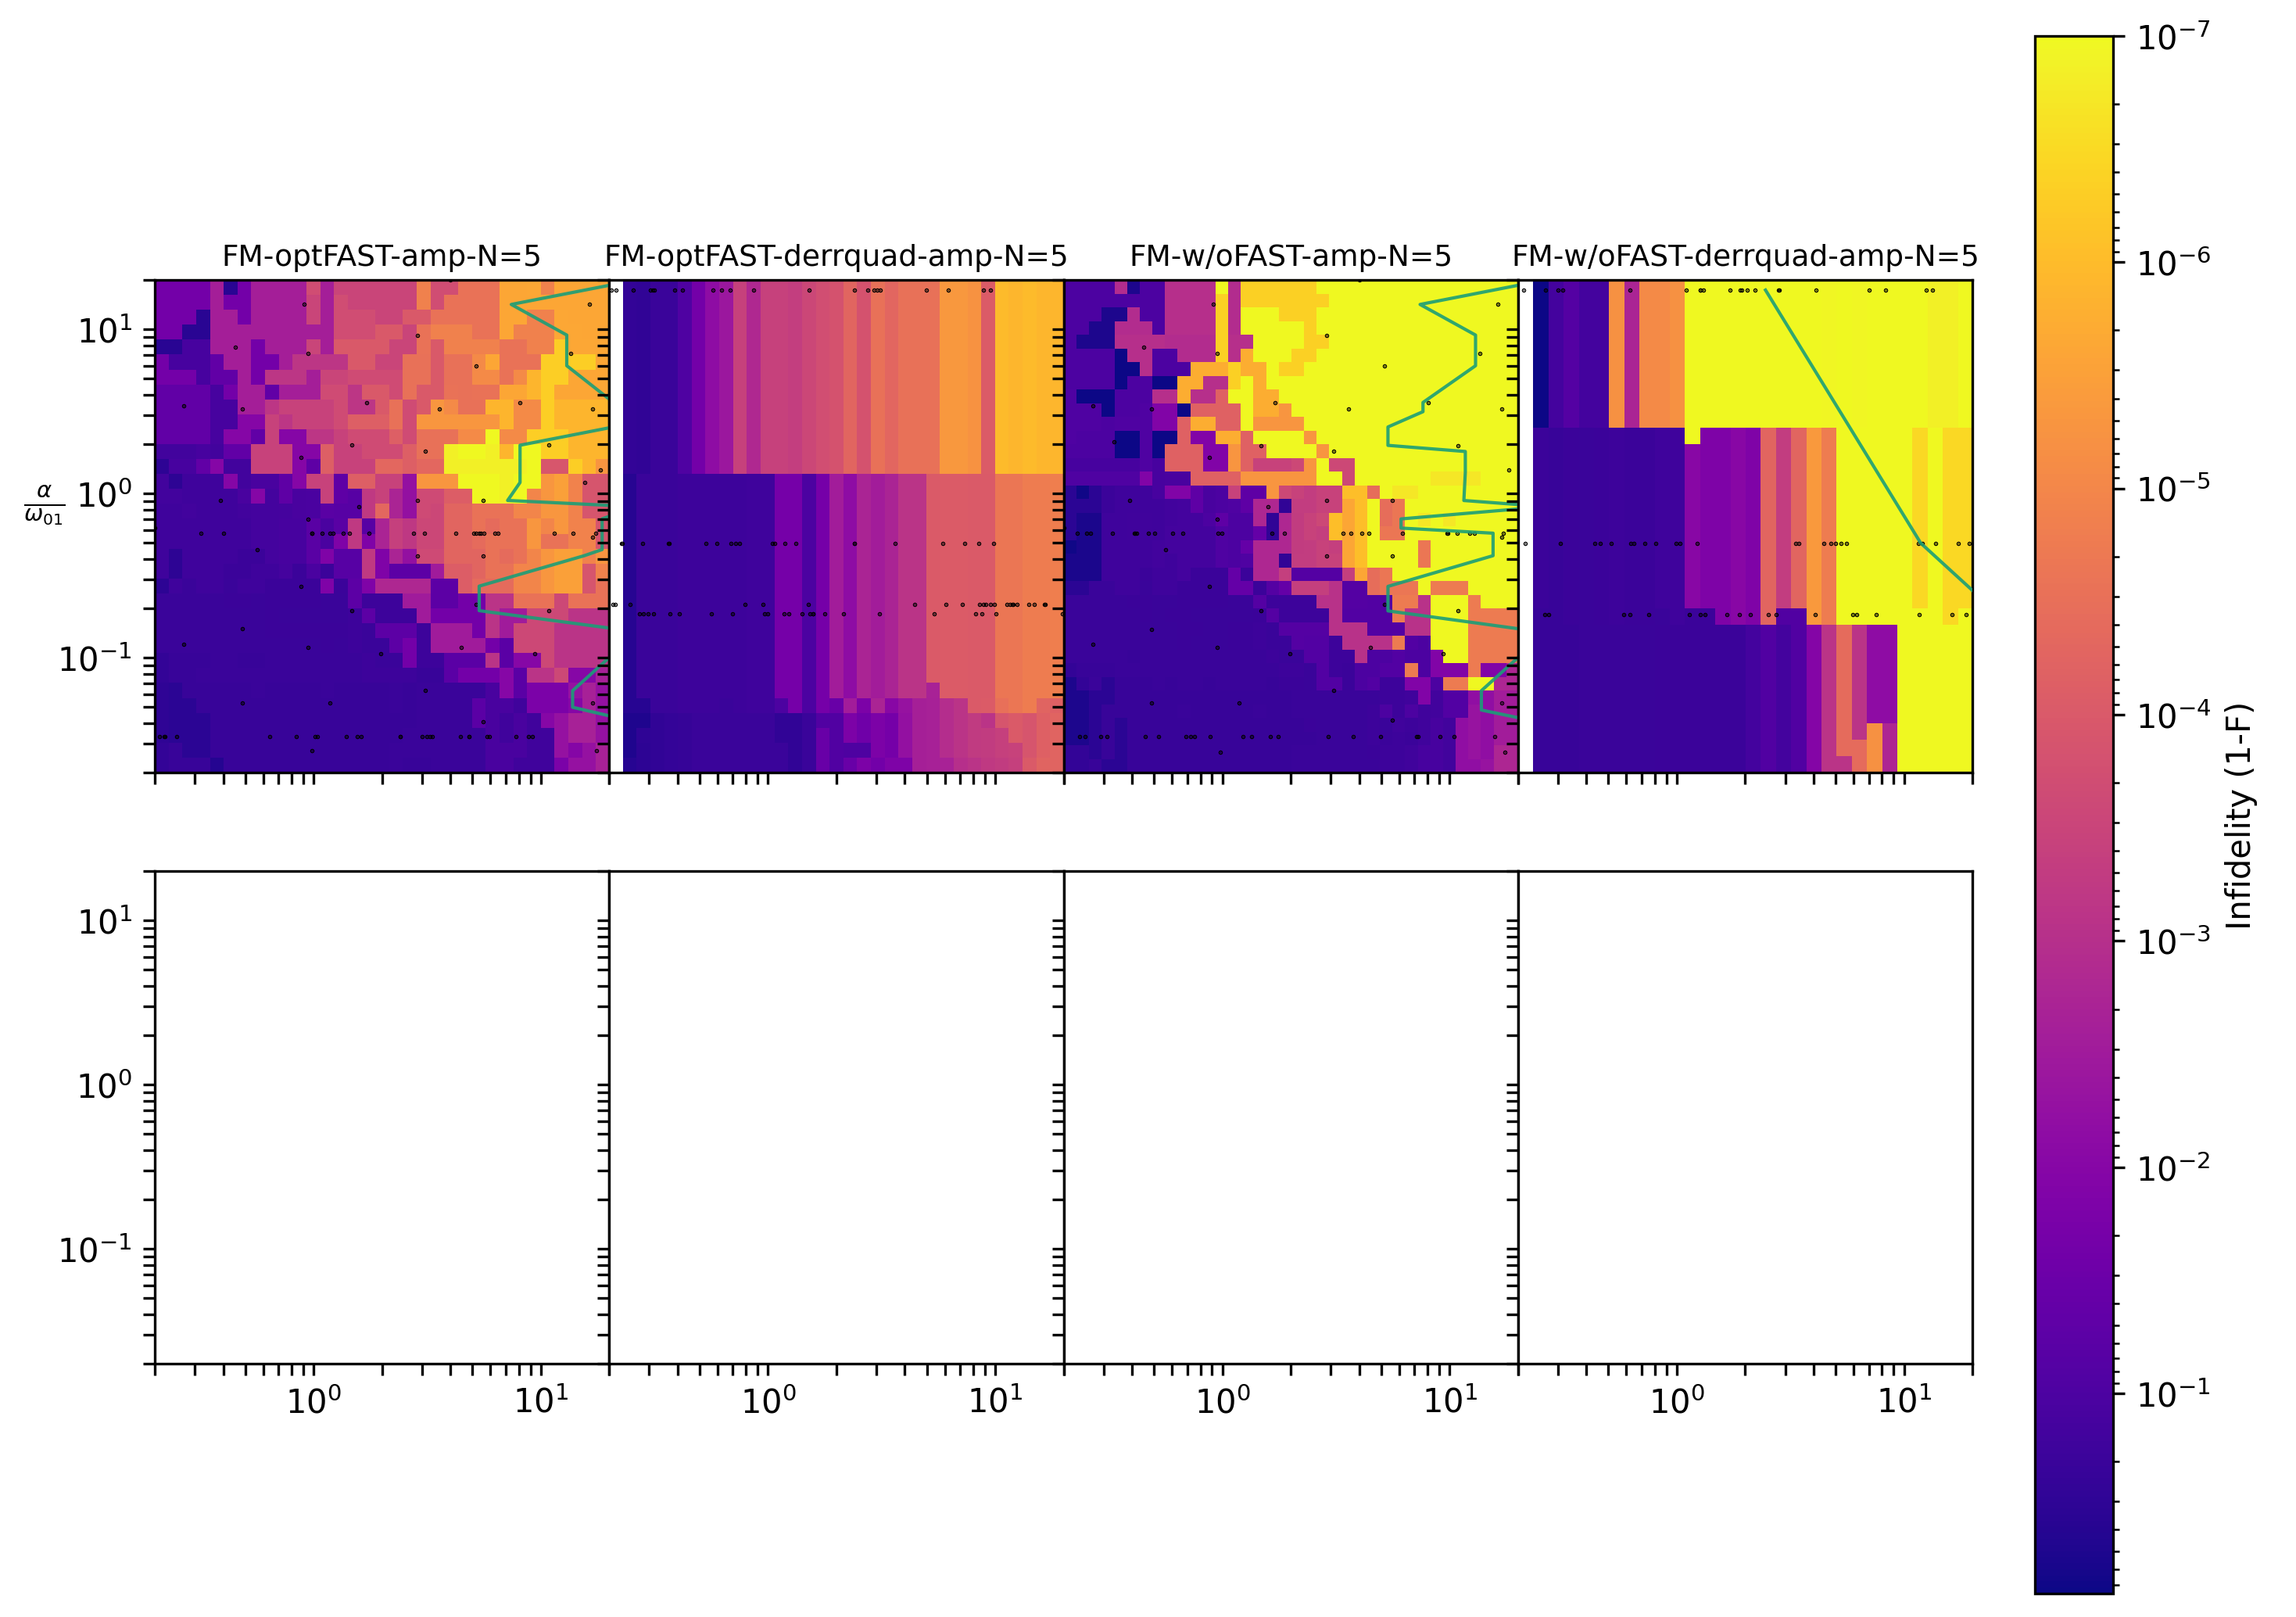

<Figure size 640x480 with 0 Axes>

'colors = {\n        "1": "#d95f02",\n        "2": "#7570b3",\n        "3": "#1b9e77"\n    }\nfig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=600)\nplt.plot([],[],label="Optima",color=colors["3"])\nplt.legend(loc=\'upper right\', fontsize=9, frameon=False, ncol=1, handletextpad=0.2)\nplt.show()'

In [ ]:
#with open("../../scores_withmetavarcap_alpha20_itt8_N=3_doubleB_varalpha.pickle", "rb") as f:

with open("../../scores_withmeta_nexttofinal_nocommround.pickle", "rb") as f:
    scores_alpha_1 = pickle.load(f)
with open("../../scores_withmeta_finalMultiDecay.pickle", "rb") as f:
    scores_alpha_2 = pickle.load(f)
scores_alpha = copy(scores_alpha_2)
for k in scores_alpha_1:
    if "comm" not in k:
        for item in scores_alpha_1[k]:
            scores_alpha[k].append(item)
with open("../../scores_withmeta_2307_N5FMtests.pickle", "rb") as f:
    scores_alpha = pickle.load(f)
plot_axes = [
    "Lambdas",
    "alpha_actual"
]
iso_axes = {
    "El": 1,
    "L1": 1.58e-4,
    "L2": 1.58e-4,
}
#sort entries in scores_alpha alphabetically by key
scores_alpha = {k: scores_alpha[k] for k in sorted(scores_alpha.keys())}
scores_alpha = {k: scores_alpha[k] for k in scores_alpha if k != "FAST-MAGNUS-MAGNUS" and "-N2" not in k}
for k in scores_alpha:
    print(f"Scheme {k} has {len(scores_alpha[k])} datapoints")
old = scores_alpha.copy()
scores_alpha = {k: old[k] for k in old if "comm" in k}

for k in old:
    if "comm" in k: continue
    scores_alpha[k] = old[k]
clear_buffers={
        'RWA_x_nooptim': False,
        'FAST-MAGNUS-MAGNUS': False,
        'FAST-MAGNUS-MAGNUS-amp': False,
        'FAST-MAGNUS-MAGNUS-N1': False,
        'FAST-MAGNUS-MAGNUS-N2': False,
        'FAST-MAGNUS-MAGNUS-N3': False,
        'FAST-MAGNUS-MAGNUS-monoquad': False,
        'FAST-MAGNUS-MAGNUS-dualquad': False,
        'FAST-MAGNUS-MAGNUS-fullquad': False,
        'FAST-MAGNUS-MAGNUS-fix1707-woFAST-derrquad-amp-N5': False,
        'FAST-MAGNUS-MAGNUS-fix1707-woFAST-amp-N5': False,
        'FAST-MAGNUS-MAGNUS-fix1707-hypFAST-amp-N5': True
        
    }
if 1:
    for k in clear_buffers: clear_buffers[k] = False
do2(scores_alpha,do_scatter=True, clear_buffers=clear_buffers)
plt.savefig("performance_2207_optfasts.pdf")
plt.show()
"""colors = {
        "1": "#d95f02",
        "2": "#7570b3",
        "3": "#1b9e77"
    }
fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=600)
plt.plot([],[],label="Optima",color=colors["3"])
plt.legend(loc='upper right', fontsize=9, frameon=False, ncol=1, handletextpad=0.2)
plt.show()"""

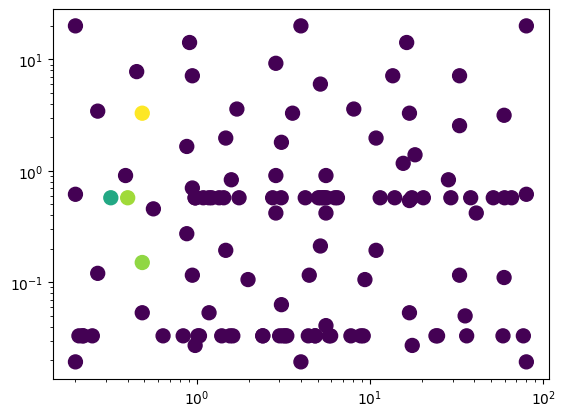

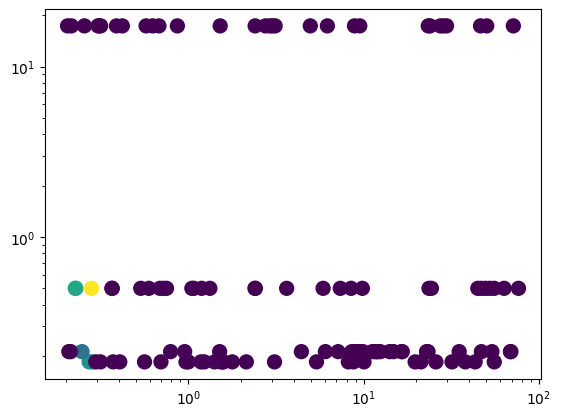

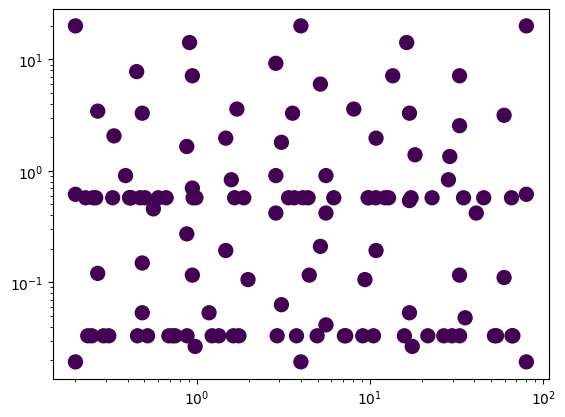

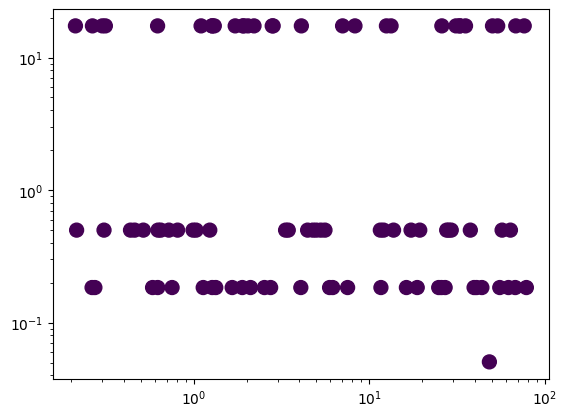

In [24]:
for k in scores_alpha:
    Lambdas = []
    alphas = []
    FASTamps = []
    for item in scores_alpha[k]:
        Lambdas.append(item["t_g"]*item["omega_01_actual"] / (2*np.pi))
        alphas.append(item["alpha_actual"])
        FASTamps.append(item["FAST_amp"])
    FASTamps = np.arctan(FASTamps)
    plt.scatter(Lambdas, alphas, s=100, label=k, c=FASTamps)
    plt.xscale("log")
    plt.yscale("log")
    plt.show()

In [5]:
def do1(scores):
    if len(plot_axes) == 1:
        print("Doing 1D plot")
        for key in scores:#key is just the gate that is attempted
            datapoints = scores[key]
            print(f"Length of set: {len(datapoints)}")
            timeouts = 0
            for i,dp in enumerate(datapoints):
                if "timeout" in dp.keys() and dp["timeout"]:
                    timeouts += 1
            print(f"Of which, {timeouts} where thrown out due to timeouts")
            other_errors = 0
            for i,dp in enumerate(datapoints):
                if dp["score"] == None:# or not (np.isinstance(dp["score"], float) or np.isinstance(dp["score"], np.float64)):
                    other_errors += 1
            print(f"Of which, {other_errors-timeouts} where thrown out due to other errors")
            distance_2_isoaxis = np.zeros(len(datapoints))
            for i,dp in enumerate(datapoints):
                for ia in iso_axes:
                    distance_2_isoaxis[i] += (dp[ia] - iso_axes[ia])**2
            distance_2_isoaxis = np.sqrt(distance_2_isoaxis)
            plot_axis = np.full(len(datapoints), np.nan)
            for i,dp in enumerate(datapoints):
                plot_axis[i] = dp[plot_axes[0]]
            score_var = np.zeros(len(datapoints))
            for i,dp in enumerate(datapoints):
                score_var[i] = dp["score"]
            nanmask = np.isnan(plot_axis) & np.isnan(score_var) & (score_var==None)
            plot_axis = plot_axis[~nanmask]
            score_var = score_var[~nanmask]
            distance_2_isoaxis = distance_2_isoaxis[~nanmask]
            distance_cut_mask = distance_2_isoaxis < 1*np.max(distance_2_isoaxis)
            lset = len(plot_axis)
            enable_color = True
            plot_axis = plot_axis[distance_cut_mask]
            score_var = score_var[distance_cut_mask]
            distance_2_isoaxis = distance_2_isoaxis[distance_cut_mask]
            #make a cmap after the distance to the plot axis
            if True:#enable_color:
                cmap = plt.cm.hot
                #norm = LogNorm(np.min(distance_2_isoaxis), np.max(distance_2_isoaxis))
                plt.scatter(plot_axis, score_var, c=distance_2_isoaxis, cmap=cmap, s=10, alpha=0.7)
                #plt.scatter(plot_axis, scores)
                plt.colorbar(label="Distance to isoaxis")
            else:
                plt.scatter(plot_axis, scores, s=10, alpha=0.7)
            plt.title(f'Scheme "{key}" scores')
            plt.xlabel(fr"${plot_axes[0]}$ ns")
            plt.ylabel("Fidelity")
            #plt.xscale("log")
            plt.show()


In [6]:
plot_axes = [
    "t_g",
    "alpha",
]
extra_axis = [
    None,
    None
]
iso_axes = {
    "El": 1,
    "L1": 1.58e-4,
    "L2": 1.58e-4,
}
do2()
score_maps = do2(force_res=60*3)

TypeError: do2() missing 2 required positional arguments: 'score_dict' and 'clear_buffers'

In [ ]:
key0 = list(score_maps.keys())[0]
cof_len = len(score_maps[key0])
cof_array = []
for i in range(len(score_maps[key0])):
    cof_array.append([])
    for j in range(len(score_maps[key0])):
        cof_array[i].append([])
        for k,key in enumerate(score_maps):
            cof_array[i][j].append(score_maps[key][i,j])
            #normalize 
        #cof_array[i][j] /= np.sum(cof_array[i][j])
        cof_array[i][j] -= np.min(cof_array[i][j])
        #cof_array[i][j] /= np.max(cof_array[i][j])
        cof_array[i][j] *= 80
cof_array = np.array(cof_array)

#not put the two datasets in the same picture with their own colormaps
cs = ["Greens", "Blues", "Reds"]
#green_map  = plt.get_cmap("Greens")
#red_map    = plt.get_cmap("Reds")
#blue_map   = plt.get_cmap("Blues")
maps = [plt.get_cmap(cs[i]) for i in range(len(cs))]
def cof2color(cof,maps):
    color_rgbs = []
    for i in range(len(cof)):
        rgb = maps[i](cof[i])
        color_rgbs.append(rgb)
    color_rgbs = np.array(color_rgbs)
    color_rgbs = np.mean(color_rgbs, axis=0)
    color_rgbs = np.array([color_rgbs[i] for i in range(len(color_rgbs)) if i != 3])
    return color_rgbs

#plot
fig, ax = plt.subplots()
fig.set_size_inches(5, 5)
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
ax.set_title("Winning fidelity map")
ax.set_xlabel(fr"${plot_axes[0]}$ [ns]")
ax.set_ylabel(fr"${plot_axes[1]}$ [GHz]")
Z_rgbs = np.zeros((cof_len, cof_len, 3))
for i in range(cof_len):
    for j in range(cof_len):
        Z_rgbs[i,j] = cof2color(cof_array[i,j], maps)
Z_rgbs = Z_rgbs.reshape((cof_len, cof_len, 3))
all_points = []
for key in scores:
    dps = scores[key]
    for dp in dps:
        axvar1 = dp[plot_axes[0]]
        axvar2 = dp[plot_axes[1]]
        all_points.append((axvar1,axvar2))
all_points = np.array(all_points).T
X = np.linspace(np.min(all_points[0]), np.max(all_points[0]), cof_len)
Y = np.linspace(np.min(all_points[1]), np.max(all_points[0]), cof_len)
X, Y = np.meshgrid(X, Y)
ax.imshow(Z_rgbs, extent=(np.min(all_points[0]), np.max(all_points[0]), np.min(all_points[1]), np.max(all_points[1])), origin="lower", aspect="auto")
ax.scatter([0],[0],c=maps[0](0.5), s=100, label=f"Scheme = {list(scores.keys())[0]}")
ax.scatter([0],[0],c=maps[1](0.5), s=100, label=f"Scheme = {list(scores.keys())[1]}")
plt.xlim(np.min(all_points[0]), np.max(all_points[0]))
plt.ylim(np.min(all_points[1]), np.max(all_points[1]))
plt.legend()
plt.show()

NameError: name 'score_maps' is not defined